**姓名：** 朱振涛  |  **学号：** BC25219010
### 一、 数据集特性与预处理
* **数据集：** 采用 SVHN Format 2，包含 73,257 张 32x32 的 RGB 彩色训练图和 26,032 张测试图。
* **预处理逻辑：**
  * 使用 `ToTensor()` 将图像像素标准化至 [0.0, 1.0]。
  * 应用 `Normalize` 进行均值和标准差归一化，将输入分布调整至 [-1.0, 1.0]，以消除量纲影响并加速网络收敛。
* **加载优化：** 使用 `DataLoader` 进行批量加载（Batch Size = 64），并利用 `download=True` 确保云端环境下数据集的完整性。

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import time

# 1. 检查并配置计算设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 定义图像预处理流水线
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. 自动下载并加载训练集和测试集
train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transform)

# 4. 构建数据加载器
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"数据加载完毕！训练集容量: {len(train_dataset)} | 测试集容量: {len(test_dataset)}")

数据加载完毕！训练集容量: 73257 | 测试集容量: 26032


### 二、 网络架构设计与对比
为了探究模型深度对分类效果的影响，实验设计并搭建了两种架构：
* **SimpleCNN：** 采用两层卷积与最大池化层组合，最后衔接两层全连接层，作为基础的 Baseline 模型。
* **ResNet-18：** 引入了残差连接。其核心在于通过恒等映射的“捷径（Shortcut）”缓解深层网络中的梯度消失问题，使得包含 18 层的深层网络能够顺利收敛，更深入地提取图像的抽象特征。

In [10]:
# ==========================================
# 架构 A：基础卷积神经网络 (SimpleCNN)
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ==========================================
# 架构 B：深度残差网络 (ResNet-18)
# ==========================================
class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResNet(nn.Module):
    def __init__(self):
        super(ResNet, self).__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        self.linear = nn.Linear(512, 10)

    def _make_layer(self, in_planes, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer4(self.layer3(self.layer2(self.layer1(out))))
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        return self.linear(out)

### 三、 训练超参数与通用验证引擎
实验采用交叉熵损失函数（CrossEntropyLoss）处理十分类问题，并使用具有自适应学习率特性的 Adam 优化器。
* **Batch Size:** 64
* **Learning Rate:** 0.001
* **Epochs:** 10

为了严格执行控制变量法，本实验封装了一个通用的 `train_and_eval` 引擎，该引擎会在每一个 Epoch 结束后立刻对测试集进行全量验证，并同步记录四个核心指标（Train Loss, Test Loss, Train Acc, Test Acc），为后续的对比绘图提供完整的数据支撑。

In [11]:
# 封装通用的训练与全量验证流程
def train_and_eval(model, model_name, num_epochs=10):
    print(f"===========================================")
    print(f"🚀 开始训练与全量验证: {model_name}")
    print(f"===========================================")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    start_time = time.time()

    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = 100. * train_correct / train_total

        # 验证阶段
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_acc = 100. * test_correct / test_total

        # 记录并打印数据
        history['train_loss'].append(epoch_train_loss)
        history['test_loss'].append(epoch_test_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        print(f"[{model_name}] Epoch {epoch+1:02d} | Train Acc: {epoch_train_acc:.2f}%, Test Acc: {epoch_test_acc:.2f}% | Train Loss: {epoch_train_loss:.4f}, Test Loss: {epoch_test_loss:.4f}")

    total_time = time.time() - start_time
    print(f"✅ {model_name} 训练完毕，最终测试准确率: {epoch_test_acc:.2f}% (耗时: {total_time/60:.2f} 分钟)\n")
    return history, epoch_test_acc

### 四、 实验结果与现象分析

通过全量监控两组模型在 10 个 Epoch 中的表现，结合绘制的 2x2 性能对比矩阵，得出以下现象分析：

**1. 收敛速度与最终精度（Performance）**
* **SimpleCNN** 的测试准确率增长较为平缓，最终遭遇瓶颈，停留在 **88.04%**。
* **ResNet-18** 则展现了降维打击般的特征提取能力。它在第 1 轮迭代结束时，测试准确率就突破了 90%（90.54%），最终收敛于 **94.29%**，实现了超 6% 的绝对精度飞跃。

**2. 泛化能力与过拟合诊断（Overfitting Analysis）**
* **SimpleCNN 的 U 型反弹**：观察其 Loss 曲线发现，Train Loss 始终在稳步逼近 0（最终降至 0.1850）。然而，Test Loss 在第 6 轮降至最低点（约 0.4320）后，出现了明显的“拐头向上”趋势（最终攀升至 0.4828）。这是典型的过拟合现象，表明两层卷积网络在训练后期失去了泛化能力，开始“死记硬背”训练集中的特异性噪声。
* **ResNet-18 的残差优势**：ResNet 的 Train Loss 降得极低（0.0478），说明其对复杂数据的拟合能力极强。更为关键的是，其 Test Loss 的绝对值远低于 SimpleCNN。尽管在第 4 轮后也出现了极其微弱的震荡上升，但整体维持在 0.25 左右的低位。这有力地证明了残差连接（Shortcut Connection）不仅能加深网络，更能有效保护梯度，缓解过拟合导致的性能退化。

🚀 开始训练与全量验证: SimpleCNN
[SimpleCNN] Epoch 01 | Train Acc: 71.53%, Test Acc: 83.24% | Train Loss: 0.9031, Test Loss: 0.6020
[SimpleCNN] Epoch 02 | Train Acc: 85.77%, Test Acc: 84.46% | Train Loss: 0.4954, Test Loss: 0.5324
[SimpleCNN] Epoch 03 | Train Acc: 87.91%, Test Acc: 85.80% | Train Loss: 0.4165, Test Loss: 0.4937
[SimpleCNN] Epoch 04 | Train Acc: 89.26%, Test Acc: 86.91% | Train Loss: 0.3678, Test Loss: 0.4560
[SimpleCNN] Epoch 05 | Train Acc: 90.10%, Test Acc: 87.26% | Train Loss: 0.3328, Test Loss: 0.4406
[SimpleCNN] Epoch 06 | Train Acc: 91.01%, Test Acc: 87.59% | Train Loss: 0.3045, Test Loss: 0.4338
[SimpleCNN] Epoch 07 | Train Acc: 91.66%, Test Acc: 87.81% | Train Loss: 0.2799, Test Loss: 0.4326
[SimpleCNN] Epoch 08 | Train Acc: 92.34%, Test Acc: 88.11% | Train Loss: 0.2579, Test Loss: 0.4290
[SimpleCNN] Epoch 09 | Train Acc: 92.91%, Test Acc: 87.57% | Train Loss: 0.2383, Test Loss: 0.4523
[SimpleCNN] Epoch 10 | Train Acc: 93.47%, Test Acc: 87.53% | Train Loss: 0.2191, Test 

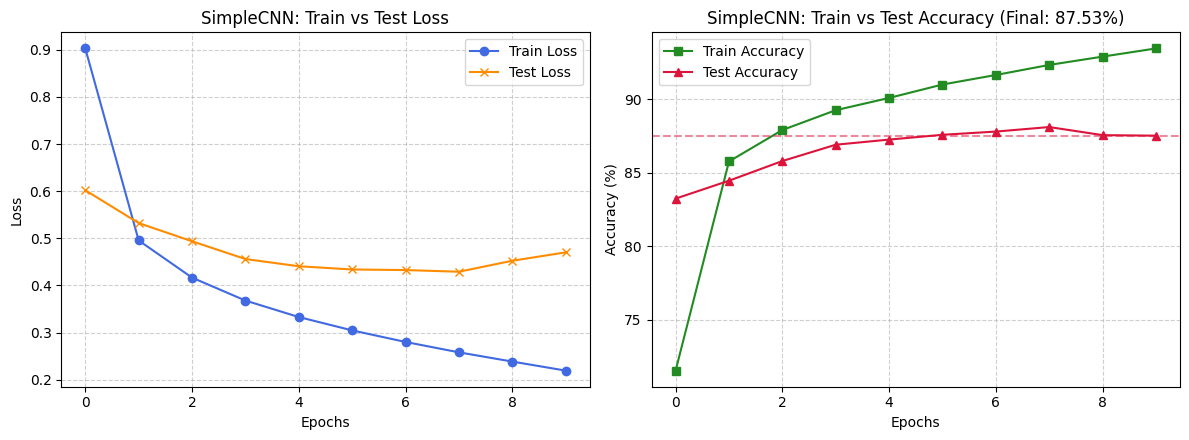

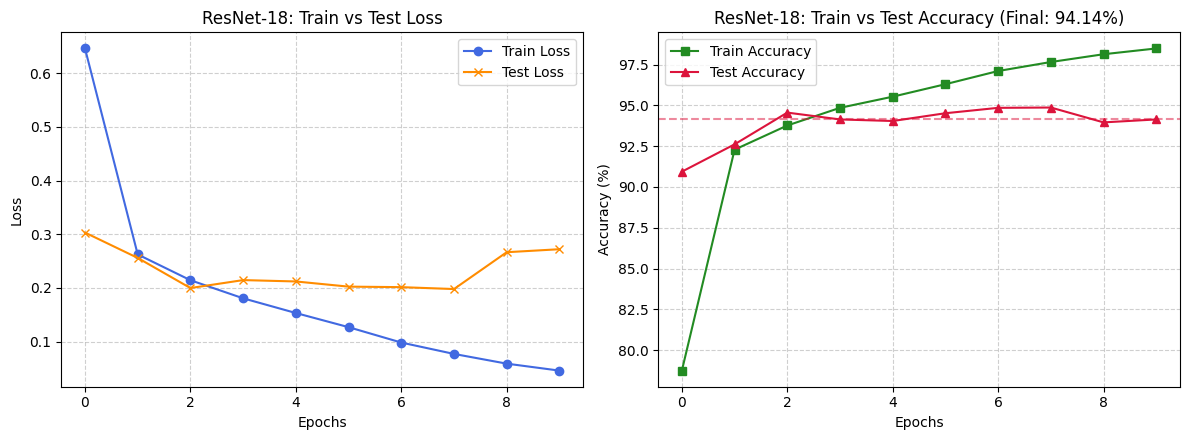

In [12]:
# 1. 实例化模型并启动控制变量对比实验
num_epochs = 10

model_simple = SimpleCNN().to(device)
model_resnet = ResNet().to(device)

history_simple, final_acc_simple = train_and_eval(model_simple, "SimpleCNN", num_epochs)
history_resnet, final_acc_resnet = train_and_eval(model_resnet, "ResNet-18", num_epochs)

# ==========================================
# 2. 绘制对比图
# ==========================================

# ----------------- 第一张图：SimpleCNN -----------------
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(history_simple['train_loss'], label='Train Loss', color='royalblue', marker='o')
plt.plot(history_simple['test_loss'], label='Test Loss', color='darkorange', marker='x')
plt.title('SimpleCNN: Train vs Test Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history_simple['train_acc'], label='Train Accuracy', color='forestgreen', marker='s')
plt.plot(history_simple['test_acc'], label='Test Accuracy', color='crimson', marker='^')
plt.axhline(y=final_acc_simple, color='crimson', linestyle='--', alpha=0.5)
plt.title(f'SimpleCNN: Train vs Test Accuracy (Final: {final_acc_simple:.2f}%)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ----------------- 第二张图：ResNet-18 -----------------
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet['train_loss'], label='Train Loss', color='royalblue', marker='o')
plt.plot(history_resnet['test_loss'], label='Test Loss', color='darkorange', marker='x')
plt.title('ResNet-18: Train vs Test Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history_resnet['train_acc'], label='Train Accuracy', color='forestgreen', marker='s')
plt.plot(history_resnet['test_acc'], label='Test Accuracy', color='crimson', marker='^')
plt.axhline(y=final_acc_resnet, color='crimson', linestyle='--', alpha=0.5)
plt.title(f'ResNet-18: Train vs Test Accuracy (Final: {final_acc_resnet:.2f}%)')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()